In [51]:
import torch
import torchvision 
import os 
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm.notebook import tqdm
import torch.nn.functional as F
plt.style.use("ggplot")

# Dataloader

In [5]:
!curl -L -o "data.zip" https://www.kaggle.com/api/v1/datasets/download/asaniczka/pc-parts-images-dataset-classification

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0

  0      0   0      0   0      0      0      0                              0
  0 34.02M   0  83245   0      0  54959      0   10:49   00:01   10:48  78105
  6 34.02M   6  2.29M   0      0 934.9k      0   00:37   00:02   00:35  1.11M
 57 34.02M  57 19.62M   0      0  5.52M      0   00:06   00:03   00:03  6.33M
100 34.02M 100 34.02M   0      0  7.77M      0   00:04   00:04          6.33M
100 34.02M 100 34.02M   0      0  7.77M      0   00:04   00:04          6.33M
100 34.02M 100 34.02M   0      0  7.77M      0   00:04   00:04          6.33M


In [7]:
!tar -xf data.zip

<BarContainer object of 14 artists>

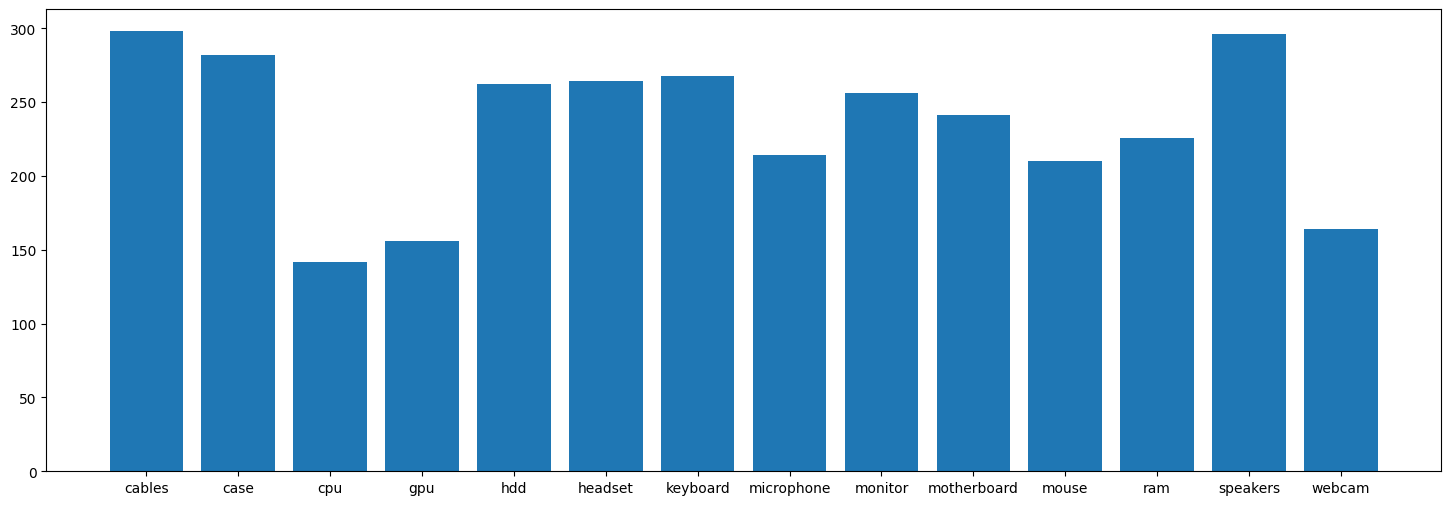

In [2]:
classes = {} 

for folder in os.listdir("pc_parts"):
    image_folder = os.path.join("pc_parts", folder)
    image_list = len(os.listdir(image_folder)) 
    classes[folder] = image_list 

num_classes = len(classes)

x = list(classes.keys()) 
y = list(classes.values())

plt.figure(figsize=(18,6))
plt.bar(x, y)

In [3]:
train_data_path = "pc_parts"

transformation = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)), 
    torchvision.transforms.ToTensor(), 
    torchvision.transforms.Normalize(mean = [0.485, 0.456, 0.406],
                                     std = [0.229, 0.224, 0.225])
])

train_data = torchvision.datasets.ImageFolder(train_data_path, transform=transformation)

In [4]:
batch_size = 512 

train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size)

# Network building

## Network 1

In [5]:
for image_data, labels in train_dataloader:
    break 

print("Shape is batch size, channels, width, height : ",image_data.shape)

Shape is batch size, channels, width, height :  torch.Size([512, 3, 64, 64])


In [16]:
def calculate_trainable_params(model):
    sum = 0
    for param in model.parameters():
        if param.requires_grad:
            sum += param.numel() # .numel() returns total number of elements in tensor
    print(sum)

In [44]:
#Create the class for the neural network which ll inherit all features and functionalities from nn.Module
class CNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__() #Do this so the current/child class can inherit all features from the parent class to use here
        self.conv1 = torch.nn.Conv2d(3, 6, 2, 2, 2) #in_channels, out_channels, kernel_size, stride, padding
        self.pool = torch.nn.MaxPool2d(2, 2)
        self.conv2 = torch.nn.Conv2d(6, 36, 2, 2, 2)
        self.conv3 = torch.nn.Conv2d(36, 48, 2, 2, 2)
        self.conv4 = torch.nn.Conv2d(48, 52, 1, 1, 1)

        self.fc1 = torch.nn.Linear(52*2*2, 256)
        self.fc2 = torch.nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x) 
        x = F.relu(x)

        x = self.conv2(x)
        x = self.pool(x)
        x = F.relu(x)
        
        x = self.conv3(x)
        x = self.pool(x)
        x = F.relu(x)

        x = self.conv4(x) 
        x = self.pool(x)
        x = F.relu(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x 



In [45]:
model = CNN(num_classes)
output = model(image_data)
print(output.shape)

torch.Size([512, 14])


In [46]:
calculate_trainable_params(model)

67588


In [47]:
criterion = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = ''
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = model.to(device)

In [50]:
epoch_list, loss_list = [], []

for epoch in tqdm(range(20)):
    training_loss = 0.0 
    training_iterator = 0
    model.train() 
    for batch in train_dataloader:
        images, labels = batch 
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step() 
        training_loss += loss.data.item() 
        training_iterator += 1 
    training_loss = training_loss / training_iterator

    epoch_list.append(epoch)
    loss_list.append(training_loss)
    print(f"Epoch : {epoch} Training Loss : {training_loss}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 Training Loss : 2.593357971736363
Epoch : 1 Training Loss : 2.5943239756992886
Epoch : 2 Training Loss : 2.5985471521105086
Epoch : 3 Training Loss : 2.606008904320853
Epoch : 4 Training Loss : 2.6170096397399902
Epoch : 5 Training Loss : 2.6292847905840193
Epoch : 6 Training Loss : 2.625577313559396
Epoch : 7 Training Loss : 2.579387528555734
Epoch : 8 Training Loss : 2.5660817623138428
Epoch : 9 Training Loss : 2.5770699637276784
Epoch : 10 Training Loss : 2.591451508658273
Epoch : 11 Training Loss : 2.6034983907427107
Epoch : 12 Training Loss : 2.624436003821237
Epoch : 13 Training Loss : 2.5964536326272145
Epoch : 14 Training Loss : 2.5766547407422746
Epoch : 15 Training Loss : 2.5875440665653775
Epoch : 16 Training Loss : 2.620540346418108
Epoch : 17 Training Loss : 2.556051083973476
Epoch : 18 Training Loss : 2.5610407761165073
Epoch : 19 Training Loss : 2.576369251523699


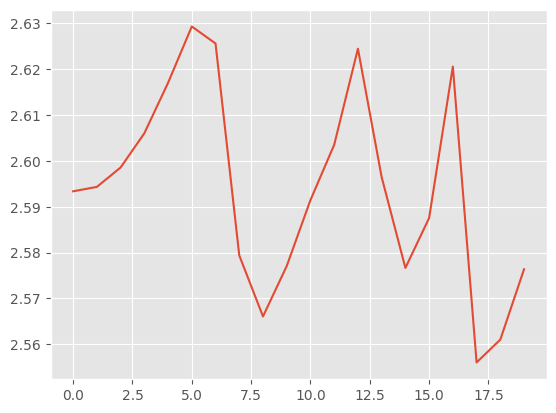

In [52]:
plt.plot(epoch_list, loss_list)

## Network 2

In [69]:
#Create the class for the neural network which ll inherit all features and functionalities from nn.Module
class CNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__() #Do this so the current/child class can inherit all features from the parent class to use here
        self.conv1 = torch.nn.Conv2d(3, 6, 2, 2, 2) #in_channels, out_channels, kernel_size, stride, padding
        self.pool = torch.nn.MaxPool2d(2, 2)
        self.conv2 = torch.nn.Conv2d(6, 12, 1, 1, 1)
        self.pool2 = torch.nn.MaxPool2d(1,1)
        self.conv3 = torch.nn.Conv2d(12, 24, 1, 1, 1)
        self.conv4 = torch.nn.Conv2d(24, 48, 1, 1, 1)
        self.conv5 = torch.nn.Conv2d(48, 96, 2, 2, 1)
        self.conv6 = torch.nn.Conv2d(96, 62, 2, 2, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x) 
        x = F.relu(x)

        x = self.conv2(x)
        x = self.pool2(x)
        x = F.relu(x)

        x = self.conv3(x)
        x = self.pool2(x) 
        x = F.relu(x)

        x = self.conv4(x)
        x = self.pool2(x)
        x = F.relu(x)

        x = self.conv5(x) 
        x = self.pool(x)
        x = F.relu(x)

        x = self.conv6(x)
        x = self.pool(x)
        x = F.relu(x)
        return x 



In [70]:
model = CNN(num_classes)
output = model(image_data)
print(output.shape)
calculate_trainable_params(model)

torch.Size([512, 62, 2, 2])
44072
